# Data Augmentation for Road-Sense Project

## Contents
1. Setup and imports
2. Visualize augmentation effects
3. Test augmentation with bounding boxes
4. Batch augmentation example

## 1. Setup and Imports

In [ ]:
import os
import sys
import warnings

warnings.filterwarnings("ignore")

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from pathlib import Path

import matplotlib.pyplot as plt

from src.data.augment_dataset import augment_dataset

# Import our custom augmentation modules
from src.data.augmentations import get_training_augmentation
from src.data.kitti_utils import load_kitti_image, load_kitti_labels, visualize_bboxes

print("✓ All imports successful")

✓ All imports successful


## 2. Visualize Augmentation Effects

Image shape: (370, 1224, 3)
Image dtype: uint8


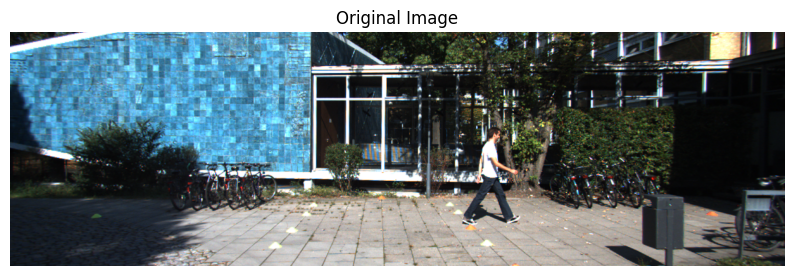

In [18]:
# Load a sample image
img_path = "../data/raw/KITTI/training/image_2/000000.png"
image = load_kitti_image(img_path)

print(f"Image shape: {image.shape}")
print(f"Image dtype: {image.dtype}")

plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

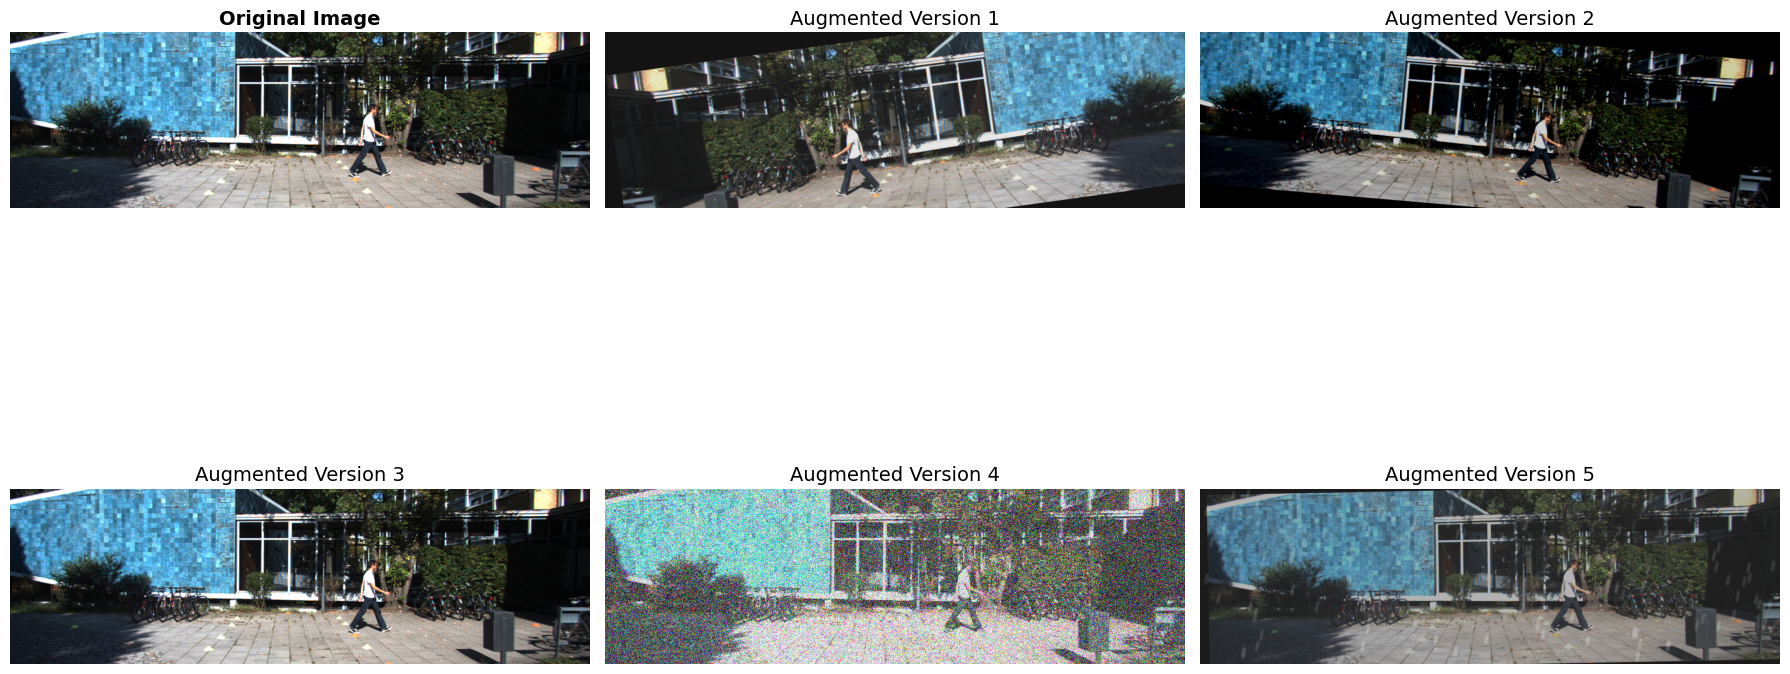

In [12]:
# Get training augmentation pipeline
transform = get_training_augmentation()

# Generate multiple augmented versions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Show original
axes[0].imshow(image)
axes[0].set_title("Original Image", fontsize=14, fontweight="bold")
axes[0].axis("off")

# Show 5 augmented versions
for i in range(1, 6):
    augmented = transform(image=image)["image"]
    axes[i].imshow(augmented)
    axes[i].set_title(f"Augmented Version {i}", fontsize=14)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 3. Test Augmentation with Bounding Boxes

Found 1 objects in the image
Classes: {'Pedestrian'}


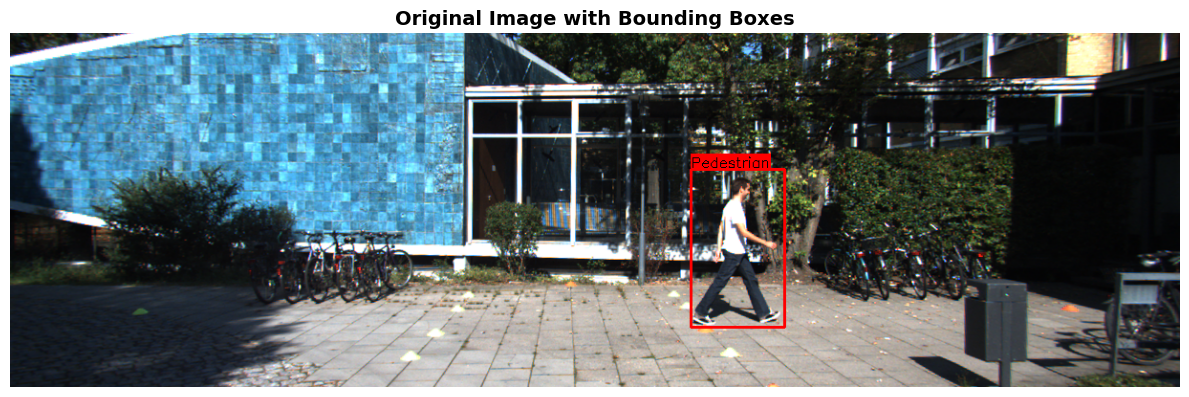

array([[[17, 22, 18],
        [16, 24, 28],
        [25, 29, 33],
        ...,
        [37, 29, 23],
        [35, 24, 21],
        [36, 17, 15]],

       [[17, 19, 16],
        [14, 23, 20],
        [24, 28, 24],
        ...,
        [37, 29, 25],
        [35, 25, 21],
        [35, 18, 14]],

       [[17, 16, 16],
        [18, 16, 19],
        [18, 21, 21],
        ...,
        [34, 29, 27],
        [32, 23, 22],
        [30, 17, 14]],

       ...,

       [[19, 23, 28],
        [17, 22, 28],
        [16, 22, 28],
        ...,
        [24, 25, 32],
        [20, 26, 32],
        [20, 27, 31]],

       [[12, 21, 28],
        [12, 19, 25],
        [14, 18, 24],
        ...,
        [20, 25, 33],
        [21, 25, 32],
        [21, 27, 30]],

       [[13, 20, 23],
        [14, 18, 18],
        [14, 17, 19],
        ...,
        [22, 30, 37],
        [22, 29, 38],
        [20, 30, 35]]], shape=(370, 1224, 3), dtype=uint8)

In [13]:
# Load image and labels
img_path = "../data/raw/KITTI/training/image_2/000000.png"
label_path = "../data/raw/KITTI/training/label_2/000000.txt"

image = load_kitti_image(img_path)
bboxes, class_labels, class_names = load_kitti_labels(label_path, image.shape[1], image.shape[0])

print(f"Found {len(bboxes)} objects in the image")
print(f"Classes: {set(class_names)}")

# Visualize original
visualize_bboxes(image, bboxes, class_names, title="Original Image with Bounding Boxes")

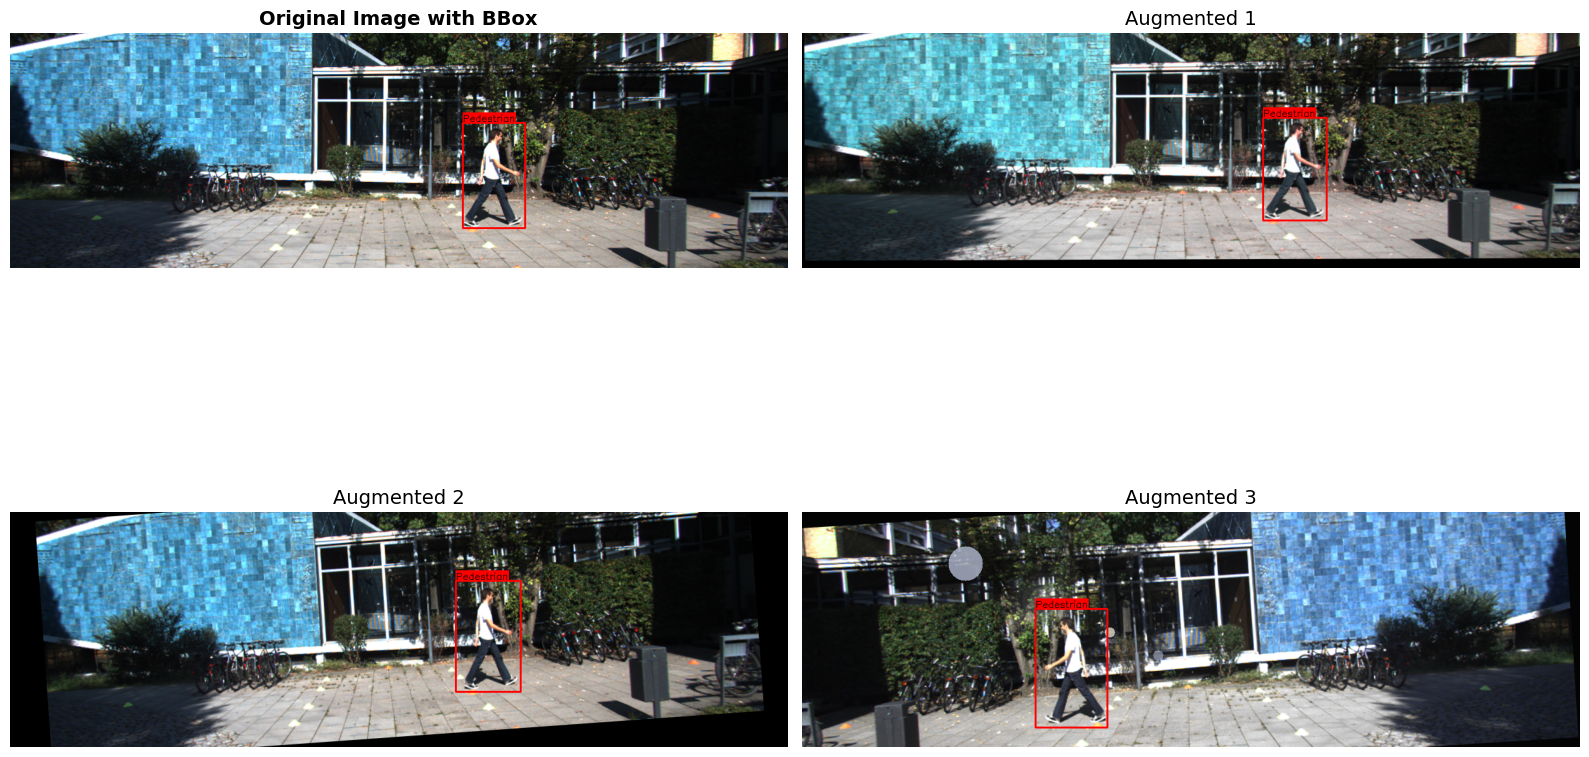

In [14]:
# Apply augmentation with bounding boxes
from src.data.augmentations import get_training_augmentation_with_bbox

transform_with_bbox = get_training_augmentation_with_bbox()

# Generate augmented versions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Show original
img_with_bbox = visualize_bboxes(image.copy(), bboxes, class_names, show=False)
axes[0].imshow(img_with_bbox)
axes[0].set_title("Original Image with BBox", fontsize=14, fontweight="bold")
axes[0].axis("off")
label_to_name = {label: name for label, name in zip(class_labels, class_names)}

# Show 3 augmented versions
for i in range(1, 4):
    try:
        augmented = transform_with_bbox(image=image, bboxes=bboxes, class_labels=class_labels)

        aug_img = augmented["image"]
        aug_boxes = augmented["bboxes"]
        aug_labels = [label_to_name.get(int(idx), str(int(idx))) for idx in augmented["class_labels"]]

        img_with_aug_bbox = visualize_bboxes(aug_img.copy(), aug_boxes, aug_labels, show=False)
        axes[i].imshow(img_with_aug_bbox)
        axes[i].set_title(f"Augmented {i}", fontsize=14)
        axes[i].axis("off")
    except Exception as e:
        axes[i].text(0.5, 0.5, f"Error: {str(e)}", ha="center", va="center", transform=axes[i].transAxes)
        axes[i].axis("off")

plt.tight_layout()
plt.show()

## 4. Batch Augmentation Example

In [15]:
# Configuration
config = {
    "img_dir": "../data/raw/KITTI/training/image_2",
    "label_dir": "../data/raw/KITTI/training/label_2",
    "output_img_dir": "../data/augmented/images",
    "output_label_dir": "../data/augmented/labels",
    "num_images": 5,  # Number of images to augment
    "augmentations_per_image": 2,  # Number of augmented versions per image
}

# Run augmentation
stats = augment_dataset(**config)

print("\nAugmentation Complete!")
print(f"Successfully processed: {stats['successful']}/{stats['total']} images")
print(f"Skipped: {stats['skipped']} images")
print(f"Failed: {stats['failed']} images")
print(f"\nOutput directory: {config['output_img_dir']}")

Starting augmentation of 5 images...
Augmentations per image: 2
Preset: medium
Output directories:
  Images: ../data/augmented/images
  Labels: ../data/augmented/labels



Augmenting images: 100%|██████████| 5/5 [00:00<00:00,  7.34it/s]


Augmentation Complete!
Successfully processed: 5/5 images
Skipped: 0 images
Failed: 0 images

Output directory: ../data/augmented/images


## 5. Verify Augmented Output

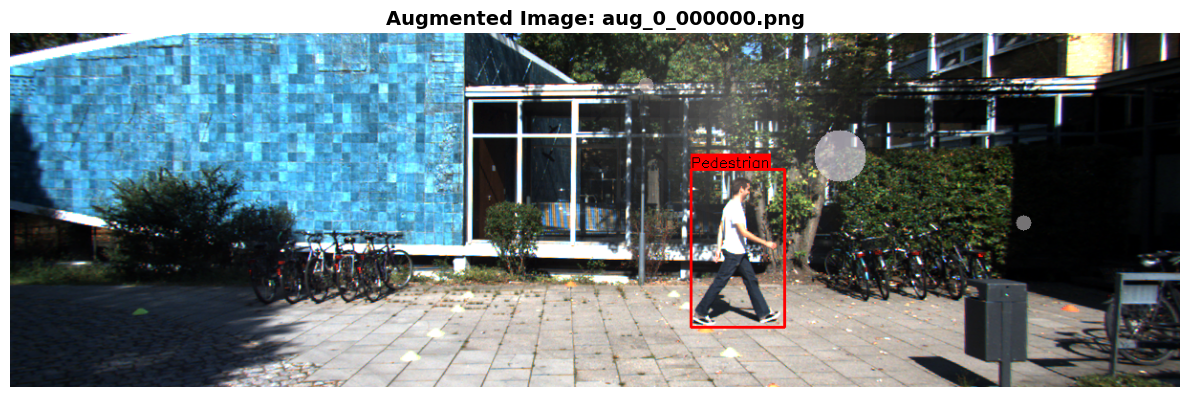


Loaded augmented image: aug_0_000000.png
Number of objects: 1


In [16]:
# Find an augmented image
aug_img_dir = Path(config["output_img_dir"])
aug_label_dir = Path(config["output_label_dir"])

aug_images = sorted(aug_img_dir.glob("*.png"))
if aug_images:
    aug_img_path = aug_images[0]
    aug_label_path = aug_label_dir / f"{aug_img_path.stem}.txt"

    aug_image = load_kitti_image(str(aug_img_path))

    from src.data.kitti_utils import load_yolo_labels

    aug_bboxes, aug_class_ids = load_yolo_labels(str(aug_label_path))
    class_id_to_name = {
        0: "Car",
        1: "Van",
        2: "Truck",
        3: "Pedestrian",
        4: "Person_sitting",
        5: "Cyclist",
        6: "Tram",
        7: "Misc",
    }
    aug_class_names = [class_id_to_name.get(cid, "Unknown") for cid in aug_class_ids]

    visualize_bboxes(aug_image, aug_bboxes, aug_class_names, title=f"Augmented Image: {aug_img_path.name}")

    print(f"\nLoaded augmented image: {aug_img_path.name}")
    print(f"Number of objects: {len(aug_bboxes)}")
else:
    print("No augmented images found. Run the batch augmentation cell first.")

The augmentation pipeline is ready for integration with the training loop using on-the-fly augmentation [our plan] .